# NHL Puck Management — Visualizations

This notebook produces the charts and visuals for the LinkedIn posts 
and Quarto blog. All visualizations are based on the final composite 
puck management rankings for the 2025-26 NHL regular season.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
import matplotlib.font_manager as fm

In [2]:
# Load final rankings
final_rankings = pd.read_csv('../data/processed/final_rankings.csv')

print(f"Total players: {len(final_rankings)}")
final_rankings.sort_values('composite_score', ascending=False).head(10)

Total players: 715


,name,team,position,games_played,metric1_giveaway_rate,metric3_dzone_giveaway_rate,metric2_above_expected,total_giveaways,I_F_dZoneShiftStarts,confidence_dzone,metric3_dzone_giveaway_weighted,icetime_minutes,confidence,metric1_weighted,metric2_weighted,metric1_z,metric2_z,metric3_z,composite_score,composite_score_weighted
167,Luke Glendening,PHI,C,70,1.082944,0.013072,0.012944,11.0,153.0,1.000000,0.013072,609.450000,0.610486,1.796329,0.008283,2.042886,1.547453,2.096186,5.686525,4.638432
691,Jamie Drysdale,PHI,D,78,1.884028,0.229167,0.008468,45.0,144.0,1.000000,0.229167,1433.100000,1.000000,1.884028,0.008468,2.677042,1.286943,0.861090,4.825075,4.394530
567,Mikey Anderson,LAK,D,80,2.114910,0.156098,0.005592,50.0,205.0,1.000000,0.156098,1418.500000,1.000000,2.114910,0.005592,2.223900,0.802141,1.720434,4.746476,3.886259
565,Alexandre Carrier,MTL,D,73,2.296361,0.173333,0.007566,43.0,150.0,1.000000,0.173333,1123.516667,1.000000,2.296361,0.007566,1.867776,1.134900,1.517730,4.520405,3.761540
467,Mathieu Olivier,CBJ,R,61,1.736832,0.048951,0.009888,23.0,143.0,1.000000,0.048951,794.550000,0.750848,2.030231,0.007668,1.615528,1.417219,1.289436,4.322182,3.677464
492,Martin Fehrvry,WSH,D,81,2.292249,0.158974,0.004575,49.0,195.0,1.000000,0.158974,1282.583333,1.000000,2.292249,0.004575,1.875847,0.630789,1.686601,4.193237,3.349936
528,Justin Faulk,DET,D,78,2.494177,0.197970,0.009464,58.0,197.0,1.000000,0.197970,1395.250000,1.000000,2.494177,0.009464,1.479533,1.454907,1.227990,4.162430,3.548435
264,Justin Hryckowian,DAL,C,81,1.393292,0.043860,0.004641,21.0,114.0,0.839344,0.053636,904.333333,0.834096,1.645652,0.004033,2.318185,0.647390,1.184085,4.149660,3.557618
222,Frederick Gaudreau,SEA,C,68,2.356192,0.034130,0.010004,36.0,293.0,1.000000,0.034130,916.733333,0.843499,2.443555,0.008592,0.860350,1.612873,1.622697,4.095920,3.284572
208,Jack Drury,COL,C,82,2.256174,0.058394,0.011120,37.0,137.0,0.971311,0.059723,983.966667,0.894482,2.325631,0.010050,1.075808,1.921741,1.047226,4.044775,3.521162


## Chart 1 — Top 20 Puck Managers

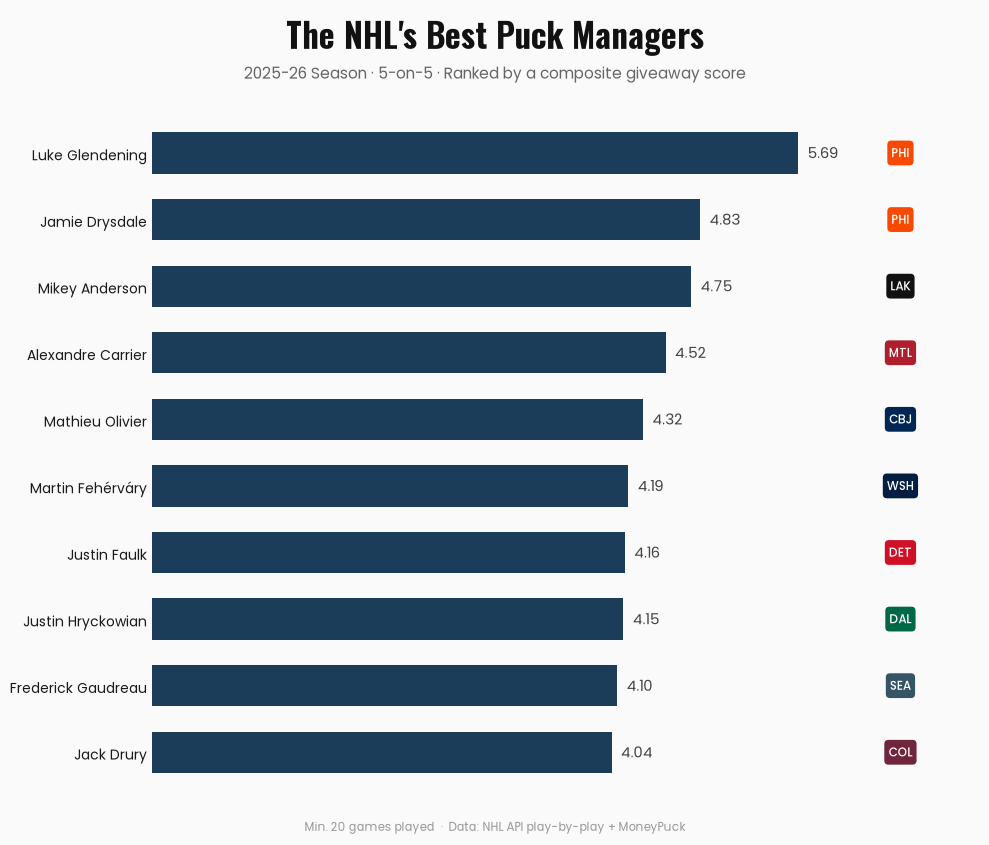

In [ ]:
TITLE_FONT = fm.FontProperties(fname='fonts/Oswald-Bold.ttf')
BODY_FONT = fm.FontProperties(fname='fonts/Poppins-Regular.ttf')
BODY_FONT_MED = fm.FontProperties(fname='fonts/Poppins-Medium.ttf')

# Fix corrupted accented names by pulling the correct spelling from the NHL API side
raw_giveaways = pd.read_csv('../data/processed/events.csv')
raw_giveaways = raw_giveaways[raw_giveaways['event_type']=='giveaway']
correct_names = raw_giveaways[['player_name']].drop_duplicates()
correct_names['name_key'] = correct_names['player_name'].apply(lambda n: n.encode('ascii', errors='ignore').decode('ascii').strip())

# Drop these if they already exist from a previous run of this cell, so it's safe to re-run
final_rankings = final_rankings.drop(columns=['name_key', 'player_name', 'display_name'], errors='ignore')

final_rankings['name_key'] = final_rankings['name'].apply(lambda n: n.encode('ascii', errors='ignore').decode('ascii').strip())
final_rankings = final_rankings.merge(correct_names, on='name_key', how='left')
final_rankings['display_name'] = final_rankings['player_name'].fillna(final_rankings['name'])

team_colors = {
    'ANA': '#F47A38', 'BOS': '#FFB81C', 'BUF': '#003087', 'CGY': '#C8102E',
    'CAR': '#CC0000', 'CHI': '#CF0A2C', 'COL': '#6F263D', 'CBJ': '#002654',
    'DAL': '#006847', 'DET': '#CE1126', 'EDM': '#FF4C00', 'FLA': '#041E42',
    'LAK': '#111111', 'MIN': '#154734', 'MTL': '#AF1E2D', 'NSH': '#FFB81C',
    'NJD': '#CE1126', 'NYI': '#00539B', 'NYR': '#0038A8', 'OTT': '#C2912C',
    'PHI': '#F74902', 'PIT': '#FCB514', 'STL': '#002F87', 'SJS': '#006D75',
    'SEA': '#355464', 'TBL': '#002868', 'TOR': '#00205B', 'UTA': '#6CACE4',
    'VAN': '#00843D', 'VGK': '#B4975A', 'WSH': '#041E42', 'WPG': '#004C97',
}

BAR_COLOR = '#1C3D5A'
BG = '#FAFAFA'

top10 = final_rankings.sort_values('composite_score', ascending=False).head(10).copy()
top10 = top10.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 8.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

y_pos = np.arange(len(top10))
ax.barh(y_pos, top10['composite_score'], color=BAR_COLOR, height=0.62, zorder=3)

for i, val in enumerate(top10['composite_score']):
    ax.text(val + 0.08, i, f'{val:.2f}', va='center', fontsize=10.5, color='#444444', fontproperties=BODY_FONT)

for i, (idx, row) in enumerate(top10.iterrows()):
    team_color = team_colors.get(row['team'], '#888888')
    ax.text(top10['composite_score'].max()+0.9, i, row['team'], va='center', ha='center',
            fontsize=8.5, color='white', fontproperties=BODY_FONT_MED,
            bbox=dict(boxstyle='round,pad=0.35', facecolor=team_color, edgecolor='none'))

ax.set_yticks(y_pos)
ax.set_yticklabels(top10['display_name'], fontsize=12.5, color='#1A1A1A', fontproperties=BODY_FONT)
ax.tick_params(axis='y', length=0)

ax.set_xlim(0, top10['composite_score'].max() + 1.6)
ax.set_ylim(-0.7, len(top10)-0.3)

ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

fig.text(0.5, 0.94, "The NHL's Best Puck Managers", fontsize=24, color='#111111',
          ha='center', fontproperties=TITLE_FONT)
fig.text(0.5, 0.905, '2025-26 Season · 5-on-5 · Ranked by a composite giveaway score',
          fontsize=11, color='#666666', ha='center', fontproperties=BODY_FONT)
fig.text(0.5, 0.02, 'Min. 20 games played  ·  Data: NHL API play-by-play + MoneyPuck',
          fontsize=8.5, color='#999999', ha='center', fontproperties=BODY_FONT)

plt.tight_layout(rect=[0, 0.04, 1, 0.89])
plt.savefig('../outputs/top10_puck_managers.png', dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()

## Chart 2  — Team Puck Management Rankings

Average composite puck management score by team. Shows which 
organizations have the best puck managers collectively.

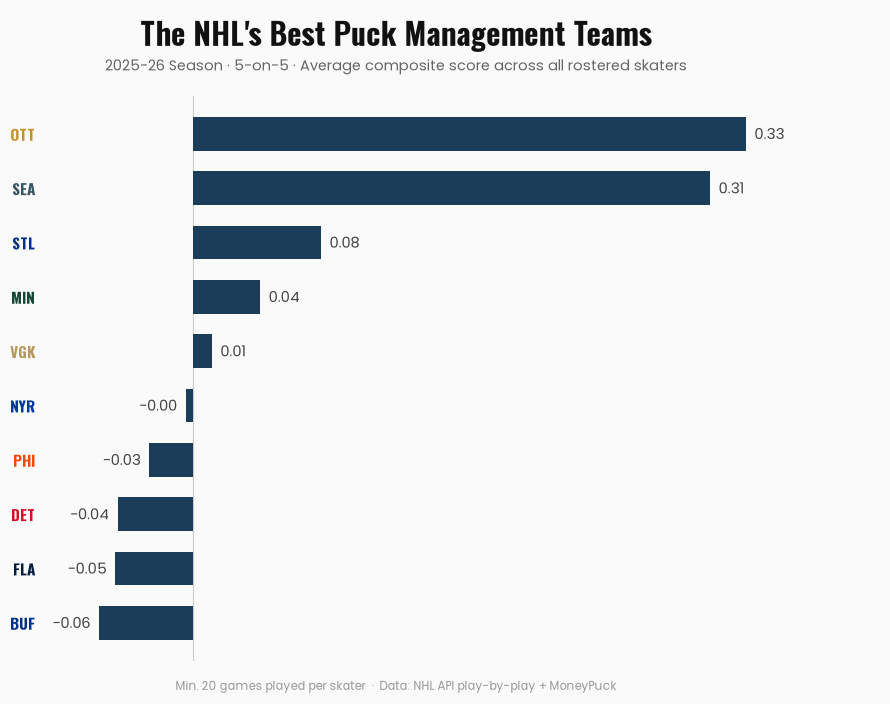

In [11]:
team_colors = {
    'ANA': '#F47A38', 'BOS': '#FFB81C', 'BUF': '#003087', 'CGY': '#C8102E',
    'CAR': '#CC0000', 'CHI': '#CF0A2C', 'COL': '#6F263D', 'CBJ': '#002654',
    'DAL': '#006847', 'DET': '#CE1126', 'EDM': '#FF4C00', 'FLA': '#041E42',
    'LAK': '#111111', 'MIN': '#154734', 'MTL': '#AF1E2D', 'NSH': '#FFB81C',
    'NJD': '#CE1126', 'NYI': '#00539B', 'NYR': '#0038A8', 'OTT': '#C2912C',
    'PHI': '#F74902', 'PIT': '#FCB514', 'STL': '#002F87', 'SJS': '#006D75',
    'SEA': '#355464', 'TBL': '#002868', 'TOR': '#00205B', 'UTA': '#6CACE4',
    'VAN': '#00843D', 'VGK': '#B4975A', 'WSH': '#041E42', 'WPG': '#004C97',
}

BAR_COLOR = '#1C3D5A'
BG = '#FAFAFA'

team_rankings = final_rankings.groupby('team').agg(
    avg_score=('composite_score', 'mean'),
    num_players=('composite_score', 'count')
).reset_index().sort_values('avg_score', ascending=False).head(10)
team_rankings = team_rankings.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

y_pos = np.arange(len(team_rankings))
ax.barh(y_pos, team_rankings['avg_score'], color=BAR_COLOR, height=0.62, zorder=3)

x_min = min(team_rankings['avg_score'].min(), 0) - 0.03
x_max = team_rankings['avg_score'].max() + 0.08
ax.set_xlim(x_min, x_max)

for i, val in enumerate(team_rankings['avg_score']):
    ha = 'left' if val >= 0 else 'right'
    offset = 0.005 if val >= 0 else -0.005
    ax.text(val + offset, i, f'{val:.2f}', va='center', ha=ha, fontsize=10.5, color='#444444', fontproperties=BODY_FONT)

for i, (idx, row) in enumerate(team_rankings.iterrows()):
    team_color = team_colors.get(row['team'], '#888888')
    ax.text(x_min - 0.008, i, row['team'], va='center', ha='right',
            fontsize=11, color=team_color, fontproperties=TITLE_FONT)

ax.axvline(x=0, color='#CCCCCC', linewidth=0.8, zorder=1)

ax.set_yticks([])
ax.set_ylim(-0.7, len(team_rankings)-0.3)
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(0.5, 0.94, "The NHL's Best Puck Management Teams", fontsize=22, color='#111111',
          ha='center', fontproperties=TITLE_FONT)
fig.text(0.5, 0.905, '2025-26 Season · 5-on-5 · Average composite score across all rostered skaters',
          fontsize=10.5, color='#666666', ha='center', fontproperties=BODY_FONT)
fig.text(0.5, 0.02, 'Min. 20 games played per skater  ·  Data: NHL API play-by-play + MoneyPuck',
          fontsize=8.5, color='#999999', ha='center', fontproperties=BODY_FONT)

plt.tight_layout(rect=[0.1, 0.04, 1, 0.89])
plt.savefig('../outputs/team_top10_puck_management.png', dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()